In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2026-04-01
Revised on 2026-04-01

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to financial data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Stock Data Vignette — yfinance
==============================

Description:
    Minimal vignette demonstrating how to fetch historical stock price
    data using yfinance and load it into a pandas DataFrame for
    exploration and visualization.

    Replaces the retired stock_data_with_pandas_datareader.ipynb.
    pandas_datareader / stooq is abandoned and broken on Python 3.14
    and pandas 3.x. yfinance is the recommended replacement.

    Steps demonstrated:
        1. Download historical OHLCV data via yf.download()
        2. Inspect the DataFrame (head, tail, info, describe)
        3. Plot the closing price time series

    For a full time series analysis and ARIMA forecast built on this
    data, see: markets_fcst_ts_arima.ipynb

Setup:
        pip install yfinance

References:
    - yfinance: https://github.com/ranaroussi/yfinance
    - Yahoo Finance: https://finance.yahoo.com

Revision History:
    2026-04-01  Original development
                - Minimal yfinance stock data fetcher
                - Replaces retired stock_data_with_pandas_datareader.ipynb
                  (pandas_datareader / stooq broken on Python 3.14 + pandas 3.x)
"""


'\nCreated on 2026-04-01\nRevised on 2026-04-01\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to financial data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nStock Data Vignette — yfinance\n==============================\n\nDescription:\n    Minimal vignette demonstrating how to fetch historical stock price\n    data using yfinance and load it into a pandas DataFrame for\n    exploration and visualization.\n\n    Replaces the retired stock_data_with_pandas_datareader.ipynb.\n    pandas_datareader / stooq is abandoned and broken on Python 3.14\n    and pandas 3.x. yfinance is the recommended replacement.\n\n    Steps demonstrated:\n        1. Download historical OHLCV data via yf.download()\n        2. Inspect the DataFrame (head, tail, info, describe)\n        3. Plot the closing price time series\n\n    For a full time series analysis and ARIMA f

# Stock Data Vignette — yfinance


# Libraries

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


/Users/otrevizo/.venvs/myenv/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


# Parameters

In [3]:
# Ticker symbol and date range
ticker = "SPY"
start = dt.datetime(2000, 1, 1)
end = dt.datetime.today()


# Fetch Data

In [4]:
# Download historical OHLCV data from Yahoo Finance
df = yf.download(ticker, start=start, end=end)


[*********************100%***********************]  1 of 1 completed


# Inspect the Data

In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2000-01-03,91.367538,93.134423,90.385936,93.134423,8164300
2000-01-04,87.794487,90.503709,87.725775,90.169964,8089800
2000-01-05,87.951591,88.913562,86.223971,87.912327,12177900
2000-01-06,86.538048,88.893893,86.538048,87.715970,6227200
2000-01-07,91.563835,91.563835,87.990804,88.147860,8066500


In [6]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-03-25,656.820007,660.890015,654.239990,658.669983,90653800
2026-03-26,645.090027,654.849976,644.820007,652.059998,96494400
2026-03-27,634.090027,642.659973,633.109985,642.500000,103649400
2026-03-30,631.969971,640.369995,629.280029,640.109985,99275900
2026-03-31,650.340027,651.539978,637.979980,638.940002,152197200


In [7]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6600 entries, 2000-01-03 to 2026-03-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   6600 non-null   float64
 1   (High, SPY)    6600 non-null   float64
 2   (Low, SPY)     6600 non-null   float64
 3   (Open, SPY)    6600 non-null   float64
 4   (Volume, SPY)  6600 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 309.4 KB


In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,6600.000000,6600.000000,6600.000000,6600.000000,6.600000e+03
mean,200.434424,201.552582,199.168789,200.415074,1.046683e+08
std,158.763296,159.509128,157.877285,158.738959,8.925752e+07
min,49.808571,51.190720,49.069940,49.691561,1.436600e+06
25%,84.785673,85.413427,84.187075,84.784236,5.096112e+07
50%,120.774258,121.100730,119.787048,120.396090,7.806585e+07
75%,263.796028,265.151674,262.351576,263.795194,1.310820e+08
max,693.595764,695.939393,692.049990,695.151505,8.710263e+08


# Plot Closing Price

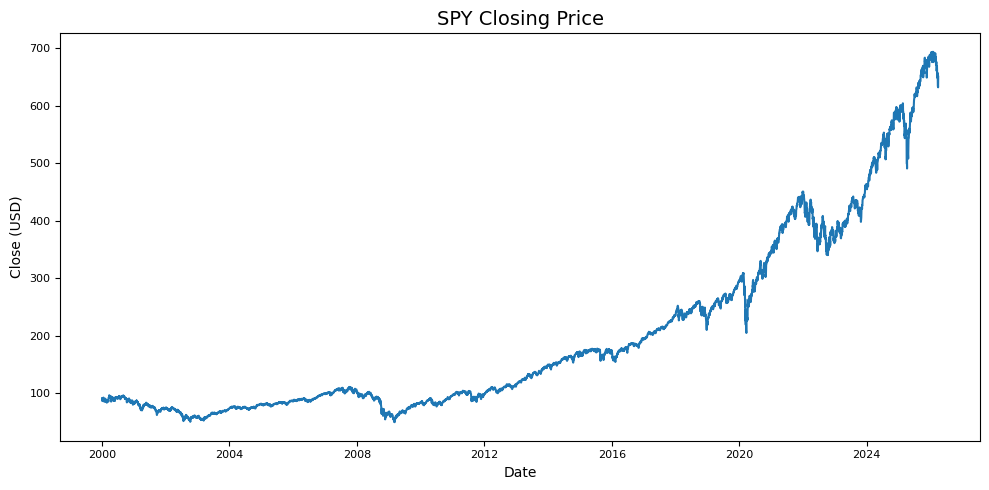

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df, x=df.index, y=("Close", ticker), ax=ax, errorbar=None)
ax.set_title(f"{ticker} Closing Price", fontsize=14)
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Close (USD)", fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()
